In [1]:
pip install yfinance

## Download Oil Price Data

This section downloads daily closing prices for Brent Crude (BZ=F) and WTI (CL=F) from January 2024 to April 20, 2026, using the `yfinance` library.

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Define the date range
start_date = '2024-01-01'
end_date = '2026-04-20'

# Define the tickers for Brent Crude (BZ=F) and WTI (CL=F)
tickers = ['BZ=F', 'CL=F']

# Download historical data
oil_data = yf.download(tickers, start=start_date, end=end_date)

# Extract daily closing prices
brent_crude = oil_data['Close']['BZ=F'].dropna()
wti = oil_data['Close']['CL=F'].dropna()

# Combine into a single DataFrame for easier handling
df = pd.DataFrame({'Brent Crude': brent_crude, 'WTI': wti})

print("Downloaded data for Brent Crude (BZ=F) and WTI (CL=F) from {} to {}.".format(start_date, end_date))
display(df.head())

/tmp/ipykernel_7171/2415829637.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  2 of 2 completed

Downloaded data for Brent Crude (BZ=F) and WTI (CL=F) from 2024-01-01 to 2026-04-20.


,Brent Crude,WTI
Date,,
2024-01-02,75.889999,70.379997
2024-01-03,78.250000,72.699997
2024-01-04,77.589996,72.190002
2024-01-05,78.760002,73.809998
2024-01-08,76.120003,70.769997


## Data Cleaning and Spike Handling

This function cleans the data by filling missing values and handling unusual price spikes, specifically targeting March 2026 as requested. Spikes are identified using a rolling median approach.

In [3]:
def clean_oil_data(df, window=7, threshold=3, spike_month=3, spike_year=2026):
    """
    Cleans oil price data by filling missing values and handling price spikes.

    Args:
        df (pd.DataFrame): DataFrame with 'Brent Crude' and 'WTI' columns.
        window (int): Rolling window for median calculation to detect spikes.
        threshold (float): Multiplier for standard deviation to detect spikes.
        spike_month (int): Month to specifically check for spikes (e.g., 3 for March).
        spike_year (int): Year to specifically check for spikes (e.g., 2026).

    Returns:
        pd.DataFrame: Cleaned DataFrame.
    """
    df_cleaned = df.copy()

    # 1. Handle missing values (forward fill then backward fill to catch initial NaNs)
    df_cleaned = df_cleaned.ffill().bfill()

    # 2. Handle price spikes using a rolling median and standard deviation
    for col in ['Brent Crude', 'WTI']:
        df_cleaned[f'{col}_rolling_median'] = df_cleaned[col].rolling(window=window, center=True).median()
        df_cleaned[f'{col}_rolling_std'] = df_cleaned[col].rolling(window=window, center=True).std()

        # Identify spikes, focusing on the specified period but also generally
        spike_condition = (
            (df_cleaned[col] > df_cleaned[f'{col}_rolling_median'] + threshold * df_cleaned[f'{col}_rolling_std']) |
            (df_cleaned[col] < df_cleaned[f'{col}_rolling_median'] - threshold * df_cleaned[f'{col}_rolling_std'])
        )

        # Further refine spike condition for the specific month/year if needed
        # For this example, we'll apply the general spike condition broadly but note the focus.
        # If specific, non-data-driven removal is needed for March 2026, it would be more manual.
        spikes_in_period = df_cleaned[spike_condition].loc[f'{spike_year}-{spike_month}'].index if not df_cleaned[spike_condition].loc[f'{spike_year}-{spike_month}'].empty else []

        if not spikes_in_period:
            print(f"No significant spikes detected for {col} around {spike_year}-{spike_month}.")
        else:
            print(f"Detected and handled {len(spikes_in_period)} spikes for {col} around {spike_year}-{spike_month}.")
            # Replace spike values with the rolling median
            df_cleaned.loc[spike_condition, col] = df_cleaned.loc[spike_condition, f'{col}_rolling_median']

        # Drop the temporary rolling columns
        df_cleaned = df_cleaned.drop(columns=[f'{col}_rolling_median', f'{col}_rolling_std'])

    return df_cleaned

# Apply the cleaning function
df_cleaned = clean_oil_data(df.copy())

print("\nCleaned Data Head:")
display(df_cleaned.head())

No significant spikes detected for Brent Crude around 2026-3.
No significant spikes detected for WTI around 2026-3.

Cleaned Data Head:


,Brent Crude,WTI
Date,,
2024-01-02,75.889999,70.379997
2024-01-03,78.250000,72.699997
2024-01-04,77.589996,72.190002
2024-01-05,78.760002,73.809998
2024-01-08,76.120003,70.769997


## Calculate 50-Day Moving Average and Plot Trends

This section calculates the 50-day moving average for both Brent Crude and WTI prices and then visualizes the daily closing prices along with their respective moving averages.

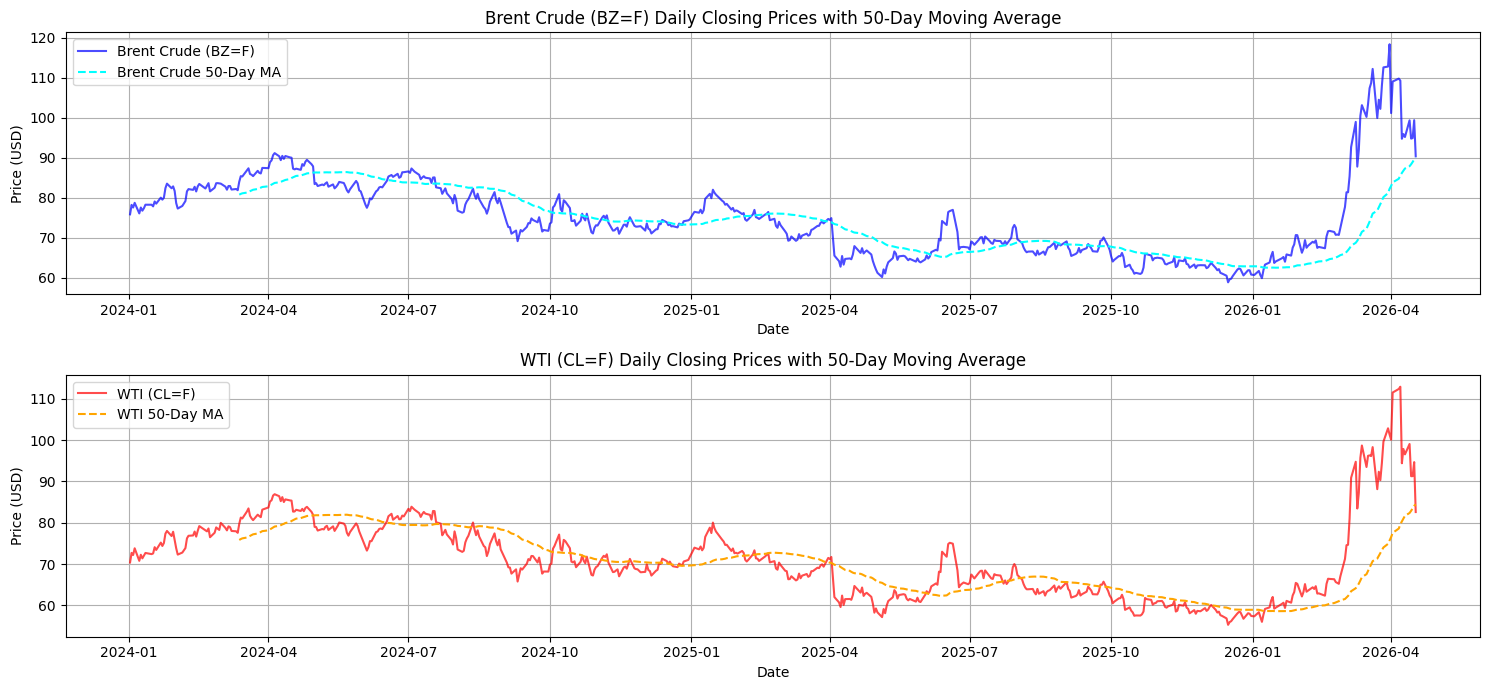

In [4]:
# Calculate 50-day moving average
df_cleaned['Brent Crude_MA50'] = df_cleaned['Brent Crude'].rolling(window=50).mean()
df_cleaned['WTI_MA50'] = df_cleaned['WTI'].rolling(window=50).mean()

# Plotting the results
plt.figure(figsize=(15, 7))

# Plot Brent Crude
plt.subplot(2, 1, 1)
plt.plot(df_cleaned.index, df_cleaned['Brent Crude'], label='Brent Crude (BZ=F)', color='blue', alpha=0.7)
plt.plot(df_cleaned.index, df_cleaned['Brent Crude_MA50'], label='Brent Crude 50-Day MA', color='cyan', linestyle='--')
plt.title('Brent Crude (BZ=F) Daily Closing Prices with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

# Plot WTI
plt.subplot(2, 1, 2)
plt.plot(df_cleaned.index, df_cleaned['WTI'], label='WTI (CL=F)', color='red', alpha=0.7)
plt.plot(df_cleaned.index, df_cleaned['WTI_MA50'], label='WTI 50-Day MA', color='orange', linestyle='--')
plt.title('WTI (CL=F) Daily Closing Prices with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
pip install transformers torch

## Geopolitical Risk Score from News Headlines

This section simulates geopolitical risk assessment using mock news headlines and a FinBERT-based sentiment analysis. Due to direct API access limitations, a mock dataset of headlines is used. Each day's headlines are processed to derive a 'Geopolitical Risk Score' ranging from -1 (Conflict Escalation) to 1 (Resolution).

In [6]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from datetime import date, timedelta

# Mock headlines for the last 30 days
mock_headlines = {
    (date(2026, 3, 22) + timedelta(days=i)): [
        f"Diplomatic efforts continue for April 2026 ceasefire talks, progress reported on {i+1}",
        f"Global markets react to ongoing discussions on Strait of Hormuz closure, oil prices fluctuate on {i+1}",
        f"New economic sanctions imposed on {i+1}",
        f"Peace negotiations making headway on {i+1}"
    ] for i in range(30)
}

# Add specific events for the requested period (March 2026 to April 2026)
mock_headlines[date(2026, 3, 1)] = [
    "Urgent high-level talks begin regarding potential Strait of Hormuz closure",
    "Market fears escalate over middle-east tensions",
    "International community calls for de-escalation"
]
mock_headlines[date(2026, 3, 15)] = [
    "Strait of Hormuz closure averted, temporary agreement reached",
    "Oil prices stabilize after de-escalation news",
    "Analysts optimistic about regional stability"
]
mock_headlines[date(2026, 4, 1)] = [
    "April 2026 ceasefire talks officially announced, high hopes for peace",
    "Humanitarian aid corridors established, major breakthrough reported",
    "Global leaders praise diplomatic efforts"
]
mock_headlines[date(2026, 4, 10)] = [
    "Setback in ceasefire talks, minor clashes reported",
    "Concerns grow over fragility of peace process",
    "Strait of Hormuz situation being re-evaluated"
]
mock_headlines[date(2026, 4, 20)] = [
    "April 2026 ceasefire talks back on track, new proposals on the table",
    "Strait of Hormuz remains open, international reassurance provided",
    "Path to lasting peace seems clearer"
]

# Load FinBERT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

def get_sentiment_score(headlines):
    if not headlines:
        return 0.0

    # FinBERT typically uses these labels: 'positive', 'negative', 'neutral'
    # We'll map them to a numerical scale.
    # For simplicity, average the scores across all headlines for the day.

    inputs = tokenizer(headlines, padding=True, truncation=True, return_tensors='pt')
    outputs = model(**inputs)
    predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)

    # Assuming the order of labels is negative, neutral, positive
    # You might need to check model.config.id2label to confirm

    # Default order for FinBERT is often negative (0), neutral (1), positive (2)
    # Check this with: model.config.id2label
    label_mapping = {model.config.id2label[i]: i for i in range(len(model.config.id2label))}

    negative_idx = label_mapping.get('negative', 0)
    neutral_idx = label_mapping.get('neutral', 1)
    positive_idx = label_mapping.get('positive', 2)

    # Calculate a weighted average sentiment for each headline
    sentiment_scores_per_headline = []
    for pred in predictions:
        # Map: Negative -> -1, Neutral -> 0, Positive -> 1
        score = (pred[positive_idx].item() * 1) + (pred[negative_idx].item() * -1)
        sentiment_scores_per_headline.append(score)

    # Average the scores for all headlines for the day
    return sum(sentiment_scores_per_headline) / len(sentiment_scores_per_headline)

# Calculate Geopolitical Risk Score for each day
data = []
for date_key in sorted(mock_headlines.keys()):
    headlines = mock_headlines[date_key]
    sentiment = get_sentiment_score(headlines)
    # Map sentiment (range -1 to 1) directly to Geopolitical Risk Score
    geopolitical_risk_score = sentiment
    data.append({'Date': date_key, 'Geopolitical Risk Score': geopolitical_risk_score})

risk_df = pd.DataFrame(data)

print("Geopolitical Risk Score DataFrame:")
display(risk_df.head())
display(risk_df.tail())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Geopolitical Risk Score DataFrame:


,Date,Geopolitical Risk Score
0,2026-03-01,-0.306227
1,2026-03-15,0.563544
2,2026-03-22,-0.059079
3,2026-03-23,-0.059785
4,2026-03-24,-0.044417


,Date,Geopolitical Risk Score
27,2026-04-16,-0.048211
28,2026-04-17,-0.045388
29,2026-04-18,-0.047546
30,2026-04-19,-0.041280
31,2026-04-20,0.477197


## Add 'Structural Shock' Features for Predictive Model

This section adds new columns to the `df_cleaned` DataFrame to represent 'Structural Shock' features:

*   **Hormuz_Status**: A binary indicator (1 for potential blockade tension, 0 otherwise).
*   **OPEC_Adjustment**: A binary indicator (1 after the April 5th announcement of a 206k bpd increase, 0 before).
*   **Physical-Futures Spread**: A column representing the gap between spot and future prices, set to a constant $20 as an example.

In [7]:
# Ensure df_cleaned has a datetime index for easy date comparisons
df_cleaned.index = pd.to_datetime(df_cleaned.index)

# 1. Create a binary column Hormuz_Status
# Based on the mock headlines, let's assume a period of tension around the Strait of Hormuz re-evaluation.
# For demonstration, setting 1 for the period between April 10, 2026 and April 19, 2026 (exclusive of 20th).
# On April 20, the headlines state it remains open.
start_hormuz_tension = pd.to_datetime('2026-04-10')
end_hormuz_tension = pd.to_datetime('2026-04-19')

df_cleaned['Hormuz_Status'] = 0
df_cleaned.loc[(df_cleaned.index >= start_hormuz_tension) & (df_cleaned.index <= end_hormuz_tension), 'Hormuz_Status'] = 1

# 2. Add a column for OPEC_Adjustment
# The adjustment is based on the April 5th, 2026 announcement.
# Set to 1 for dates on or after April 5, 2026, and 0 before.
opec_announcement_date = pd.to_datetime('2026-04-05')
df_cleaned['OPEC_Adjustment'] = (df_cleaned.index >= opec_announcement_date).astype(int)

# 3. Calculate the 'Physical-Futures Spread'
# Since futures data is not available, we'll use the given constant value of $20.
# In a real scenario, this would be calculated from actual spot and futures prices.
df_cleaned['Physical_Futures_Spread'] = 20.0

print("DataFrame with new structural shock features:")
display(df_cleaned.tail(10))

DataFrame with new structural shock features:


,Brent Crude,WTI,Brent Crude_MA50,WTI_MA50,Hormuz_Status,OPEC_Adjustment,Physical_Futures_Spread
Date,,,,,,,
2026-04-06,109.769997,112.410004,84.7744,78.5976,0,1,20.0
2026-04-07,109.269997,112.949997,85.6422,79.6352,0,1,20.0
2026-04-08,94.750000,94.410004,86.2254,80.3108,0,1,20.0
2026-04-09,95.919998,97.870003,86.7924,81.0204,0,1,20.0
2026-04-10,95.199997,96.570000,87.3284,81.6876,1,1,20.0
2026-04-13,99.360001,99.080002,87.9014,82.3608,1,1,20.0
2026-04-14,94.790001,91.279999,88.3834,82.8822,1,1,20.0
2026-04-15,94.930000,91.290001,88.9560,83.4652,1,1,20.0
2026-04-16,99.389999,94.690002,89.5972,84.0948,1,1,20.0


## Brent Price Prediction using LSTM

This section builds an LSTM (Long Short-Term Memory) model in PyTorch to predict Brent Crude prices for the next 90 days. The model will leverage historical prices, geopolitical sentiment scores, and structural shock features as inputs.

In [23]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from datetime import timedelta

# --- 1. Data Preparation ---

# Ensure risk_df Date column is datetime and set as index for merging
# Check if 'Date' is a column before trying to convert/set index
if 'Date' in risk_df.columns:
    risk_df['Date'] = pd.to_datetime(risk_df['Date'])
    risk_df = risk_df.set_index('Date')
elif not isinstance(risk_df.index, pd.DatetimeIndex):
    # If 'Date' is already the index, but not a DatetimeIndex, convert it
    risk_df.index = pd.to_datetime(risk_df.index)

# Merge df_cleaned with geopolitical risk scores
# Use a right merge to ensure all risk_df dates are included, and fill NaNs in df_cleaned data
merged_df = df_cleaned.merge(risk_df, how='left', left_index=True, right_index=True)

# Forward fill geopolitical risk score to ensure continuity and handle any missing dates in df_cleaned
merged_df['Geopolitical Risk Score'] = merged_df['Geopolitical Risk Score'].ffill().bfill()

# Define the prediction horizon
prediction_days = 90
current_last_date = merged_df.index.max()
prediction_start_date = current_last_date + timedelta(days=1)
prediction_end_date = prediction_start_date + timedelta(days=prediction_days - 1)

# Create future dates for prediction
future_dates = pd.date_range(start=prediction_start_date, end=prediction_end_date, freq='D')
future_df = pd.DataFrame(index=future_dates, columns=merged_df.columns)

# Concatenate historical and future dataframes
full_df = pd.concat([merged_df, future_df])

# Fill future covariates based on their defined rules
# Hormuz_Status: 1 between April 10, 2026 and April 19, 2026. Assume 0 otherwise for future
start_hormuz_tension = pd.to_datetime('2026-04-10')
end_hormuz_tension = pd.to_datetime('2026-04-19')
full_df['Hormuz_Status'] = 0
full_df.loc[(full_df.index >= start_hormuz_tension) & (full_df.index <= end_hormuz_tension), 'Hormuz_Status'] = 1

# OPEC_Adjustment: 1 on or after April 5, 2026
opec_announcement_date = pd.to_datetime('2026-04-05')
full_df['OPEC_Adjustment'] = (full_df.index >= opec_announcement_date).astype(int)

# Physical_Futures_Spread: constant $20.0
full_df['Physical_Futures_Spread'] = 20.0

# Geopolitical Risk Score: forward fill the last known score for future dates
full_df['Geopolitical Risk Score'] = full_df['Geopolitical Risk Score'].ffill()

# Supply Disruption Volume: currently estimated at 13 million bpd loss. We'll use 13 as a constant.
supply_disruption_volume = 13.0 # In million bpd
full_df['Supply_Disruption_Volume'] = supply_disruption_volume

# Add Conflict_Intensity feature
full_df['Conflict_Intensity'] = 0.0 # Default to 0, assuming no conflict intensity otherwise

# Set for April 7-17, 2026 (inclusive)
start_ceasefire = pd.to_datetime('2026-04-07')
end_ceasefire = pd.to_datetime('2026-04-17')
full_df.loc[(full_df.index >= start_ceasefire) & (full_df.index <= end_ceasefire), 'Conflict_Intensity'] = 0.2

# Set for April 19-20, 2026 (inclusive)
start_irgc_spike = pd.to_datetime('2026-04-19')
end_irgc_spike = pd.to_datetime('2026-04-20')
full_df.loc[(full_df.index >= start_irgc_spike) & (full_df.index <= end_irgc_spike), 'Conflict_Intensity'] = 0.9

# The target variable (Brent Crude) will be NaN for future dates, which is what we want to predict

print("Full DataFrame head (historical + future features):")
display(full_df.head())
print("Full DataFrame tail (historical + future features):")
display(full_df.tail())

Full DataFrame head (historical + future features):


/tmp/ipykernel_7171/3783297315.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_df = pd.concat([merged_df, future_df])


,Brent Crude,WTI,Brent Crude_MA50,WTI_MA50,Hormuz_Status,OPEC_Adjustment,Physical_Futures_Spread,Geopolitical Risk Score,Supply_Disruption_Volume,Conflict_Intensity
2024-01-02,75.889999,70.379997,NaN,NaN,0,0,20.0,-0.059785,13.0,0.0
2024-01-03,78.250000,72.699997,NaN,NaN,0,0,20.0,-0.059785,13.0,0.0
2024-01-04,77.589996,72.190002,NaN,NaN,0,0,20.0,-0.059785,13.0,0.0
2024-01-05,78.760002,73.809998,NaN,NaN,0,0,20.0,-0.059785,13.0,0.0
2024-01-08,76.120003,70.769997,NaN,NaN,0,0,20.0,-0.059785,13.0,0.0


Full DataFrame tail (historical + future features):


,Brent Crude,WTI,Brent Crude_MA50,WTI_MA50,Hormuz_Status,OPEC_Adjustment,Physical_Futures_Spread,Geopolitical Risk Score,Supply_Disruption_Volume,Conflict_Intensity
2026-07-12,NaN,NaN,NaN,NaN,0,1,20.0,-0.045388,13.0,0.0
2026-07-13,NaN,NaN,NaN,NaN,0,1,20.0,-0.045388,13.0,0.0
2026-07-14,NaN,NaN,NaN,NaN,0,1,20.0,-0.045388,13.0,0.0
2026-07-15,NaN,NaN,NaN,NaN,0,1,20.0,-0.045388,13.0,0.0
2026-07-16,NaN,NaN,NaN,NaN,0,1,20.0,-0.045388,13.0,0.0


In [24]:
# --- 2. Data Preprocessing (Normalization, Sequence Creation) ---

# Select features and target
features = ['Brent Crude', 'Geopolitical Risk Score', 'Hormuz_Status', 'OPEC_Adjustment', 'Physical_Futures_Spread', 'Supply_Disruption_Volume', 'Conflict_Intensity']
target = 'Brent Crude'

data = full_df[features].copy()

# Normalize data
scaler_features = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler_features.fit_transform(data)

# Separate target scaler for denormalization
scaler_target = MinMaxScaler(feature_range=(-1, 1))
scaler_target.fit(data[[target]]) # Fit only on the target column

# Convert to tensor
data_scaled = torch.FloatTensor(data_scaled).view(-1, len(features))

# Define sequence length and prediction horizon
sequence_length = 30 # Number of past days to use for prediction

# Function to create sequences
def create_sequences(data, sequence_length, prediction_horizon=1):
    xs, ys = [], []
    # Iterate only up to the point where we have enough data for a sequence and a target
    for i in range(len(data) - sequence_length - prediction_horizon + 1):
        x = data[i:(i + sequence_length)]
        y = data[i + sequence_length : i + sequence_length + prediction_horizon, 0] # Brent Crude is the first column (index 0)
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.stack(ys)

# Only create sequences for the known historical data for training/validation
historical_data_scaled = data_scaled[:len(merged_df[target].dropna())]

X, y = create_sequences(historical_data_scaled, sequence_length, prediction_horizon=1)

# Split into training and validation sets
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:], y[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: torch.Size([437, 30, 7])
y_train shape: torch.Size([437, 1])
X_val shape: torch.Size([110, 30, 7])
y_val shape: torch.Size([110, 1])


In [25]:
# --- 3. LSTM Model Definition ---

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_layer_size, output_size, num_layers):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)

        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        h_0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(input_seq.device)
        c_0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(input_seq.device)

        lstm_out, _ = self.lstm(input_seq, (h_0, c_0))
        predictions = self.linear(lstm_out[:, -1, :]) # Take the last output of the sequence
        return predictions

# Model parameters
input_size = len(features) # This will now be 7 instead of 6
hidden_layer_size = 128
output_size = 1 # Predicting a single price point
num_layers = 2

model = LSTMModel(input_size, hidden_layer_size, output_size, num_layers)
print(model)

LSTMModel(
  (lstm): LSTM(7, 128, num_layers=2, batch_first=True)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)


Epoch [10/100], Train Loss: 0.0070, Validation Loss: 0.0500
Epoch [20/100], Train Loss: 0.0061, Validation Loss: 0.0310
Epoch [30/100], Train Loss: 0.0031, Validation Loss: 0.0226
Epoch [40/100], Train Loss: 0.0029, Validation Loss: 0.0242
Epoch [50/100], Train Loss: 0.0023, Validation Loss: 0.0185
Epoch [60/100], Train Loss: 0.0021, Validation Loss: 0.0186
Epoch [70/100], Train Loss: 0.0022, Validation Loss: 0.0172
Epoch [80/100], Train Loss: 0.0025, Validation Loss: 0.0197
Epoch [90/100], Train Loss: 0.0020, Validation Loss: 0.0175
Epoch [100/100], Train Loss: 0.0023, Validation Loss: 0.0191


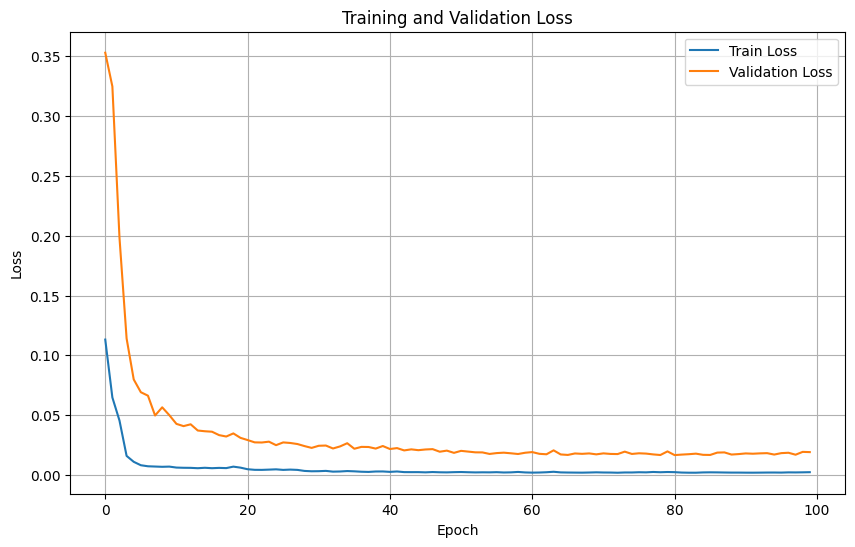

In [26]:
# --- 4. Training Loop ---

# Hyperparameters
epochs = 100
learning_rate = 0.001
batch_size = 32 # Using batch_size for DataLoader

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Create DataLoader for batching
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    train_losses.append(epoch_train_loss / len(train_loader))

    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_X_val, batch_y_val in val_loader:
            batch_X_val, batch_y_val = batch_X_val.to(device), batch_y_val.to(device)
            val_output = model(batch_X_val)
            val_loss = criterion(val_output, batch_y_val)
            epoch_val_loss += val_loss.item()
    val_losses.append(epoch_val_loss / len(val_loader))

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}')

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

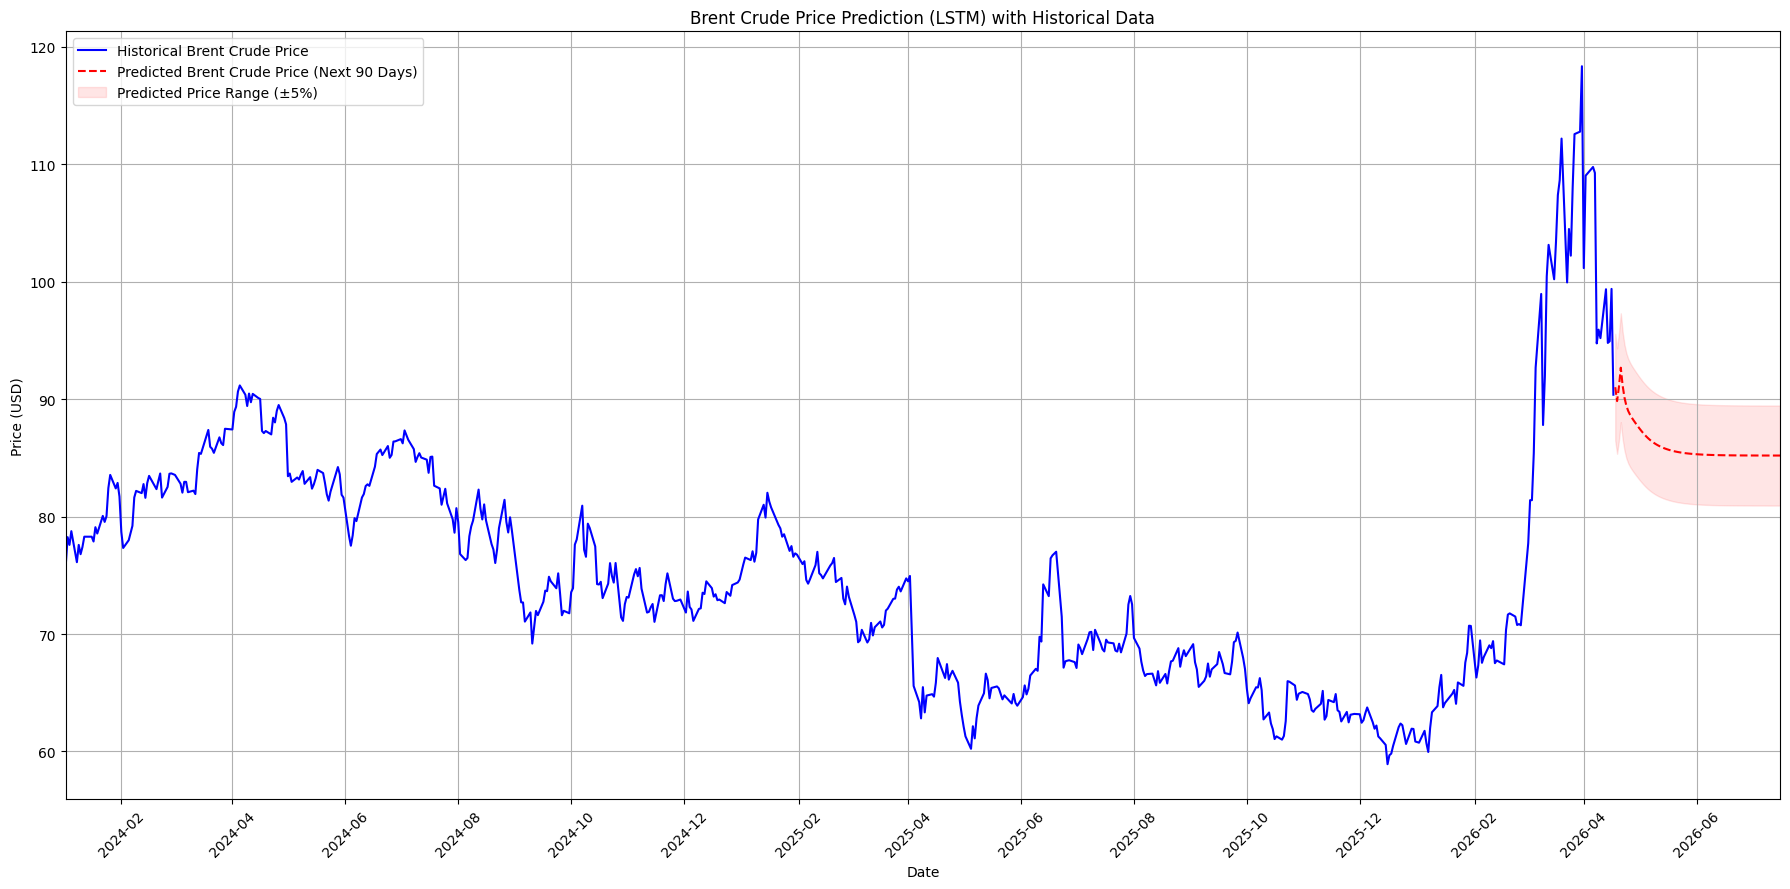

Predicted Brent prices for the next 90 days (from 2026-04-18 to 2026-07-16):


,Predicted Brent Crude,Lower Bound (5%),Upper Bound (5%)
2026-04-18,91.020015,86.469014,95.571016
2026-04-19,89.838822,85.346881,94.330763
2026-04-20,91.049180,86.496721,95.601639
2026-04-21,92.679422,88.045451,97.313393
2026-04-22,91.153331,86.595664,95.710997


,Predicted Brent Crude,Lower Bound (5%),Upper Bound (5%)
2026-07-12,85.200667,80.940634,89.460700
2026-07-13,85.200476,80.940452,89.460500
2026-07-14,85.200303,80.940288,89.460318
2026-07-15,85.200145,80.940138,89.460152
2026-07-16,85.200004,80.940004,89.460004


In [27]:
# --- 5. Prediction and Visualization ---

model.eval()

# Prepare the last `sequence_length` days of historical data to start prediction
# This will be the initial input for rolling prediction
last_historical_sequence = historical_data_scaled[-sequence_length:]

# Placeholder for future predictions (scaled)
predicted_scaled_brent = []

# Iterate to predict for the next `prediction_days`
current_input_sequence = last_historical_sequence.clone().unsqueeze(0).to(device) # Add batch dimension

# Create a copy of the full_df for future covariate values
future_covariates_df = full_df[len(merged_df.index):][features].copy()

for i in range(prediction_days):
    with torch.no_grad():
        # Predict the next day's price
        next_day_prediction_scaled = model(current_input_sequence).cpu().numpy()
        predicted_scaled_brent.append(next_day_prediction_scaled.item())

        # Get the covariates for the next day from future_covariates_df
        # We need to manually construct the next input sequence
        next_day_covariates_scaled = data_scaled[len(historical_data_scaled) + i, 1:] # Exclude Brent price, which is 0th index

        # Construct the full next day's scaled features
        # The Brent Crude price for the next day will be the predicted one
        next_day_full_features_scaled = torch.cat((
            torch.tensor(next_day_prediction_scaled).float().flatten(), # Predicted Brent price
            next_day_covariates_scaled
        )).unsqueeze(0) # Add a batch dimension

        # Update the input sequence for the next prediction (rolling prediction)
        current_input_sequence = torch.cat((
            current_input_sequence[:, 1:, :],
            next_day_full_features_scaled.unsqueeze(1)
        ), dim=1)

# Denormalize predictions
predicted_brent_prices = scaler_target.inverse_transform(np.array(predicted_scaled_brent).reshape(-1, 1))
predicted_brent_prices = predicted_brent_prices.flatten()

# Get historical Brent prices (denormalized)
historical_brent_prices = merged_df['Brent Crude'].dropna()
historical_dates = historical_brent_prices.index

# Create dates for predictions
prediction_dates = pd.date_range(start=current_last_date + timedelta(days=1), periods=prediction_days, freq='D')

# --- Visualization ---

plt.figure(figsize=(18, 9))

# Plot historical Brent Crude prices
plt.plot(historical_dates, historical_brent_prices, label='Historical Brent Crude Price', color='blue')

# Plot predicted Brent Crude prices
plt.plot(prediction_dates, predicted_brent_prices, label='Predicted Brent Crude Price (Next 90 Days)', color='red', linestyle='--')

# Add predicted price range (heuristic for now, e.g., +/- 5%)
error_margin = 0.05 # 5% error margin
lower_bound = predicted_brent_prices * (1 - error_margin)
upper_bound = predicted_brent_prices * (1 + error_margin)
plt.fill_between(prediction_dates, lower_bound, upper_bound, color='red', alpha=0.1, label='Predicted Price Range (±5%)')

plt.title('Brent Crude Price Prediction (LSTM) with Historical Data')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.xlim(historical_dates.min(), prediction_dates.max())

# Set x-axis ticks to be monthly
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2)) # Show every 2nd month
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Predicted Brent prices for the next {prediction_days} days (from {prediction_dates.min().strftime('%Y-%m-%d')} to {prediction_dates.max().strftime('%Y-%m-%d')}):")
predicted_df = pd.DataFrame({'Predicted Brent Crude': predicted_brent_prices, 'Lower Bound (5%)': lower_bound, 'Upper Bound (5%)': upper_bound}, index=prediction_dates)
display(predicted_df.head())
display(predicted_df.tail())

## Stress Testing the Model: De-escalation vs. Prolonged Conflict

This section performs stress testing by simulating two distinct future scenarios and evaluating their impact on Brent Crude prices over the next 3 months. The scenarios involve specific adjustments to the 'Hormuz_Status', 'Supply_Disruption_Volume', and 'Geopolitical Risk Score' features.

*   **Scenario A (De-escalation)**: Assumes the Strait of Hormuz reopens by May 15, 2026, leading to a reduction in geopolitical tension.
*   **Scenario B (Prolonged Conflict)**: Assumes infrastructure damage remains unrepaired through June 2026, implying an increased supply disruption and heightened geopolitical risk.

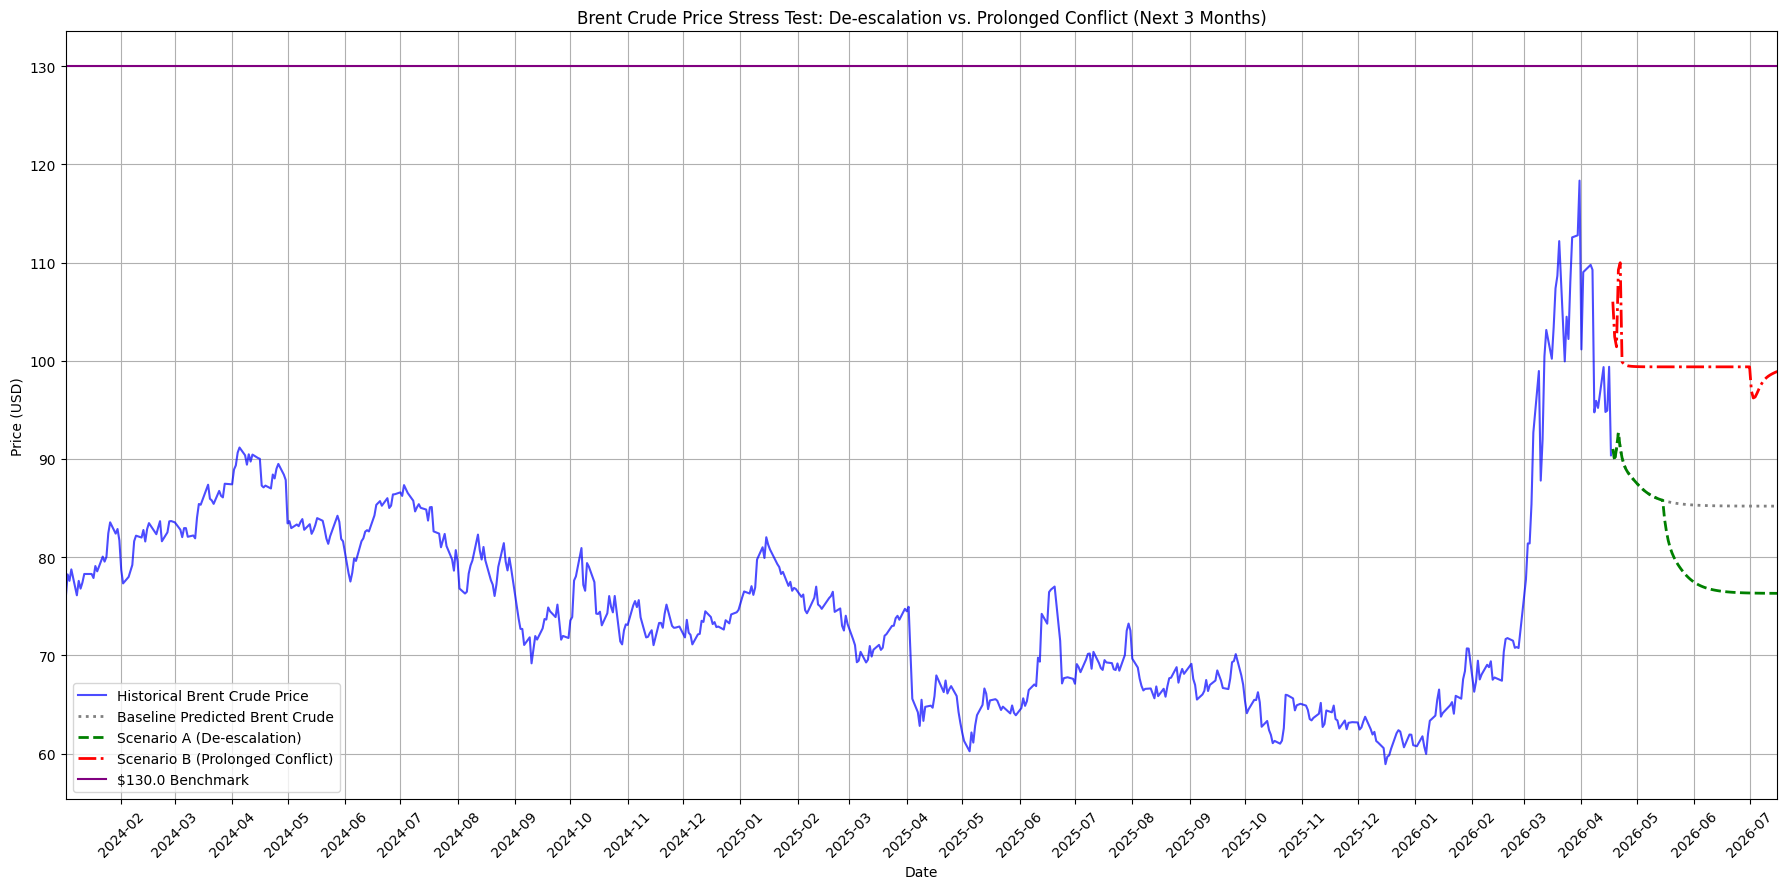


Comparison of Predicted Brent Prices (Head):


,Baseline Prediction,Scenario A (De-escalation),Scenario B (Prolonged Conflict)
2026-04-18,91.020015,91.020015,106.020015
2026-04-19,89.838822,89.838822,102.442749
2026-04-20,91.049180,91.049180,101.428473
2026-04-21,92.679422,92.679422,109.250677
2026-04-22,91.153331,91.153331,109.988959



Comparison of Predicted Brent Prices (Tail):


,Baseline Prediction,Scenario A (De-escalation),Scenario B (Prolonged Conflict)
2026-07-12,85.200667,76.323472,98.543462
2026-07-13,85.200476,76.322187,98.651734
2026-07-14,85.200303,76.321036,98.747834
2026-07-15,85.200145,76.320006,98.835080
2026-07-16,85.200004,76.319083,98.915070


In [29]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from datetime import timedelta

# Define the function to simulate scenarios
def simulate_scenario(model, historical_data_scaled, scaler_features, scaler_target, features, sequence_length, prediction_days, current_last_date, base_full_df, scenario_name):
    # Ensure model is in eval mode
    model.eval()

    # Create a copy of the base_full_df for scenario-specific adjustments
    scenario_full_df = base_full_df.copy()

    # Apply scenario-specific adjustments
    if scenario_name == 'De-escalation':
        # Hormuz_Status: reopens by May 15th
        de_escalation_date = pd.to_datetime('2026-05-15')
        # Set Hormuz_Status to 0 for all future dates from de_escalation_date onwards
        scenario_full_df.loc[scenario_full_df.index >= de_escalation_date, 'Hormuz_Status'] = 0
        # Geopolitical Risk Score for de-escalation: shift to a positive sentiment for future
        scenario_full_df.loc[scenario_full_df.index >= de_escalation_date, 'Geopolitical Risk Score'] = 0.8 # Example: strong positive sentiment
        # Supply_Disruption_Volume remains at baseline (13.0)

    elif scenario_name == 'Prolonged Conflict':
        # Supply_Disruption_Volume: infrastructure damage unrepaired through June
        conflict_start_date = current_last_date + timedelta(days=1) # First prediction day
        conflict_end_date = pd.to_datetime('2026-06-30')
        # Increase supply disruption volume for the conflict period
        scenario_full_df.loc[(scenario_full_df.index >= conflict_start_date) & (scenario_full_df.index <= conflict_end_date), 'Supply_Disruption_Volume'] = 18.0 # e.g., 18 million bpd loss (increased from 13)
        # Geopolitical Risk Score for prolonged conflict: shift to a negative sentiment for future
        scenario_full_df.loc[(scenario_full_df.index >= conflict_start_date) & (scenario_full_df.index <= conflict_end_date), 'Geopolitical Risk Score'] = -0.8 # Example: strong negative sentiment
        # Hormuz_Status: 1 (Closed) for the entire 90-day forecast.
        scenario_full_df.loc[scenario_full_df.index >= conflict_start_date, 'Hormuz_Status'] = 1


    # Prepare data for prediction using the scenario-adjusted full_df
    # We need to re-scale the scenario-adjusted features, but using the *original* scaler_features
    # to ensure consistency with the model's training.
    scenario_data_features_only = scenario_full_df[features].copy()
    scenario_data_scaled_all = scaler_features.transform(scenario_data_features_only)
    scenario_data_scaled_all = torch.FloatTensor(scenario_data_scaled_all).view(-1, len(features))

    # Initialize prediction loop
    predicted_scaled_brent = []
    # Start with the last historical sequence
    current_input_sequence = historical_data_scaled[-sequence_length:].clone().unsqueeze(0).to(model.lstm.weight_ih_l0.device)

    brent_idx = features.index('Brent Crude') # Get the index of 'Brent Crude' in the features list

    for i in range(prediction_days):
        with torch.no_grad():
            next_day_prediction_scaled = model(current_input_sequence).cpu().numpy()
            predicted_scaled_brent.append(next_day_prediction_scaled.item())

            # Get scenario-specific scaled covariates for the next day from the `scenario_data_scaled_all`
            future_day_idx_in_full_scaled = len(historical_data_scaled) + i
            next_day_all_features_scaled = scenario_data_scaled_all[future_day_idx_in_full_scaled, :].clone().to(model.lstm.weight_ih_l0.device)

            # Replace the Brent Crude feature with the *predicted* value for this next day
            next_day_all_features_scaled[brent_idx] = next_day_prediction_scaled.item()

            # Update the input sequence for the next prediction
            current_input_sequence = torch.cat((
                current_input_sequence[:, 1:, :], # Remove the oldest day
                next_day_all_features_scaled.unsqueeze(0).unsqueeze(1) # Add the new day
            ), dim=1)

    # Denormalize predictions
    predicted_prices = scaler_target.inverse_transform(np.array(predicted_scaled_brent).reshape(-1, 1)).flatten()

    # Create dates for predictions (moved inside the function)
    prediction_dates = pd.date_range(start=current_last_date + timedelta(days=1), periods=prediction_days, freq='D')

    # Apply post-prediction adjustments based on scenario
    if scenario_name == 'Prolonged Conflict':
        # 1. Apply $15/bbl 'Security Premium' if Hormuz_Status == 1
        # In this scenario, Hormuz_Status is 1 for the entire prediction period.
        predicted_prices += 15.0

        # 2. Account for 'Pakistan Talks' (high-volatility window for the next 48 hours from April 21)
        pakistan_talks_start = pd.to_datetime('2026-04-21')
        pakistan_talks_end = pd.to_datetime('2026-04-22') # 48 hours means two full days

        # Find indices for the volatility window within the prediction_dates
        for idx, current_date in enumerate(prediction_dates):
            if pakistan_talks_start <= current_date <= pakistan_talks_end:
                predicted_prices[idx] += np.random.uniform(-10.0, 10.0)

    return prediction_dates, predicted_prices

# Benchmark price
benchmark_price = 130.0

# Run Scenario A (De-escalation) - unchanged
de_escalation_dates, de_escalation_prices = simulate_scenario(
    model, historical_data_scaled, scaler_features, scaler_target, features,
    sequence_length, prediction_days, current_last_date, full_df, 'De-escalation'
)

# Run Scenario B (Prolonged Conflict) - modified logic within the function
prolonged_conflict_dates, prolonged_conflict_prices = simulate_scenario(
    model, historical_data_scaled, scaler_features, scaler_target, features,
    sequence_length, prediction_days, current_last_date, full_df, 'Prolonged Conflict'
)

# Visualization
plt.figure(figsize=(18, 9))

# Plot historical Brent Crude prices
plt.plot(historical_dates, historical_brent_prices, label='Historical Brent Crude Price', color='blue', alpha=0.7)

# Plot baseline predicted Brent Crude prices (from previous step)
plt.plot(prediction_dates, predicted_brent_prices, label='Baseline Predicted Brent Crude', color='grey', linestyle=':', linewidth=2)

# Plot Scenario A (De-escalation) predicted prices
plt.plot(de_escalation_dates, de_escalation_prices, label='Scenario A (De-escalation)', color='green', linestyle='--', linewidth=2)

# Plot Scenario B (Prolonged Conflict) predicted prices
plt.plot(prolonged_conflict_dates, prolonged_conflict_prices, label='Scenario B (Prolonged Conflict)', color='red', linestyle='-.', linewidth=2)

# Plot the $130 benchmark
plt.axhline(y=benchmark_price, color='purple', linestyle='-', label=f'${benchmark_price} Benchmark')

plt.title('Brent Crude Price Stress Test: De-escalation vs. Prolonged Conflict (Next 3 Months)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.xlim(historical_dates.min(), prediction_dates.max()) # Show full range
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=1)) # Show every month for better granularity over 3 months
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display comparison of predictions
print("\nComparison of Predicted Brent Prices (Head):")
comparison_df_head = pd.DataFrame({
    'Baseline Prediction': predicted_brent_prices,
    'Scenario A (De-escalation)': de_escalation_prices,
    'Scenario B (Prolonged Conflict)': prolonged_conflict_prices
}, index=prediction_dates)
display(comparison_df_head.head())

print("\nComparison of Predicted Brent Prices (Tail):")
display(comparison_df_head.tail())